## Dane ze spinal sluza jako zrodlo dla modelu operujacego na zdjeciach

In [1]:
import os
import sys
import logging

# Silence Hugging Face internet retry warnings in offline environments.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"

logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub.file_download").setLevel(logging.ERROR)

try:
    from huggingface_hub import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

sys.path.insert(0, r"D:\Politechnika\Deadlift_publikacja_nr_2 — kopia\Skrypty\github")

from utils.datasets import YOLOPoseDataset
from utils.validation import YPSetValidation, MergedRankingEvaluator



c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import importlib
import utils.validation.merged_ranking_evaluator as _yp_validation_test_mod

importlib.reload(_yp_validation_test_mod)
MergedRankingEvaluator = _yp_validation_test_mod.MergedRankingEvaluator

In [3]:
x=10
dataset = YOLOPoseDataset(r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_angle_preserving_out_"+str(x)+r"\train.txt")
validator = YPSetValidation(dataset)
validator.get_stats()

{'total_images': 263,
 'total_persons': 263,
 'total_keypoints': 3156,
 'total_visible_keypoints': 3156,
 'avg_keypoints_per_image': 12.0,
 'avg_keypoints_per_person': 12.0,
 'avg_visible_keypoints_per_image': 12.0,
 'avg_visible_keypoints_per_person': 12.0,
 'dataset_file': 'D:\\Politechnika\\Deadlift_publikacja_nr_2\\tiger_pose_walidacja\\tiger-pose_angle_preserving_out_10\\train.txt',
 'labels_dir': 'D:\\Politechnika\\Deadlift_publikacja_nr_2\\tiger_pose_walidacja\\tiger-pose_angle_preserving_out_10\\labels'}

**#TIGER**

In [4]:

def test(x):
    dataset = YOLOPoseDataset(r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_angle_preserving_out_"+str(x)+r"\train.txt")
    validator = YPSetValidation(dataset)


    rigid_report_path = (
        r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_angle_preserving_out_"
        + str(x)
        + r"\results.txt"
    )

    report_paths = {
        "rigid_aligned": rigid_report_path,
    }

    evaluator = MergedRankingEvaluator(
        validator=validator,
        report_paths=report_paths,
        top_k=x,
        output_path=None,
        distance_model_name="random_forest",
        distance_visibility_threshold=2.0,
        distance_threshold_percentile=95.0,
        distance_sort_by="mean",
        segmentation_model_name=None,
        segmentation_mask_tolerance_px=18,
    )

    result = evaluator.run(
        distance_weight=0.8,
        lbp_weight=0.2,
        segmentation_weight=0.0,
    )

    if not result:
        return None
    return result["report_details"]["rigid_aligned"]

In [5]:
test_tiger_10=test(10)

test_tiger_10


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 133.52it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 133.24it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:09<00:00, 28.35it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.800/0.200/0.000 | merged=6/10 | overall=10/10 | avg_rank_all=8.10 | rigid_aligned=6/10 | overall=10/10 | avg_rank_all=8.10
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 6,
 'total_reference_entries': 10,
 'matched_overall_count': 10,
 'avg_rank_all_reference': 8.1,
 'last_matched_rank_in_top_k': 10}

In [6]:
test_tiger_25=test(25)
test_tiger_25

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 134.45it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 136.20it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:09<00:00, 29.13it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.800/0.200/0.000 | merged=14/25 | overall=25/25 | avg_rank_all=30.00 | rigid_aligned=14/25 | overall=25/25 | avg_rank_all=30.00
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 14,
 'total_reference_entries': 25,
 'matched_overall_count': 25,
 'avg_rank_all_reference': 30.0,
 'last_matched_rank_in_top_k': 23}

In [7]:
test_tiger_50=test(50)
test_tiger_50

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 135.06it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 134.11it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:08<00:00, 29.23it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.800/0.200/0.000 | merged=36/50 | overall=50/50 | avg_rank_all=39.78 | rigid_aligned=36/50 | overall=50/50 | avg_rank_all=39.78
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 36,
 'total_reference_entries': 50,
 'matched_overall_count': 50,
 'avg_rank_all_reference': 39.78,
 'last_matched_rank_in_top_k': 45}

In [8]:
test_tiger_100=test(100)
test_tiger_100

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 136.06it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:01<00:00, 136.57it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:08<00:00, 29.37it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.800/0.200/0.000 | merged=76/100 | overall=100/100 | avg_rank_all=69.41 | rigid_aligned=76/100 | overall=100/100 | avg_rank_all=69.41
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 76,
 'total_reference_entries': 100,
 'matched_overall_count': 100,
 'avg_rank_all_reference': 69.41,
 'last_matched_rank_in_top_k': 100}

**#SPINAL**

In [9]:

def test(x):
    dataset = YOLOPoseDataset(
        r"D:\Politechnika\Deadlift_publikacja_nr_2\spinal_pose_walidacja\spinal_pose_1000_angle_preserving_out_"+str(x)+r"\train.txt"
    )
    validator = YPSetValidation(dataset)

    rigid_report_path = (
        r"D:\Politechnika\Deadlift_publikacja_nr_2\spinal_pose_walidacja\spinal_pose_1000_angle_preserving_out_"+str(x)+r"\results.txt"
    )

    report_paths = {
        "rigid_aligned": rigid_report_path,
    }

    evaluator = MergedRankingEvaluator(
        validator=validator,
        report_paths=report_paths,
        top_k=x,
        output_path=None,
        distance_model_name="random_forest",
        distance_visibility_threshold=2.0,
        distance_threshold_percentile=95.0,
        distance_sort_by="mean",
        segmentation_mask_tolerance_px=24,
    )

    result = evaluator.run(
        distance_weight=0.5,
        lbp_weight=0.1,
        segmentation_weight=0.4,
    )

    if not result:
        return None
    return result["report_details"]["rigid_aligned"]

In [10]:
spinal_test_50 = test(50)
spinal_test_50

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:08<00:00, 112.63it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:08<00:00, 113.10it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:37<00:00, 26.54it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 90.36it/s]


weights=0.500/0.100/0.400 | merged=19/50 | overall=50/50 | avg_rank_all=200.28 | rigid_aligned=19/50 | overall=50/50 | avg_rank_all=200.28
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=982 | segmentation_without_mask=18 | outside=21 | outside_person_total=21 | outside_persons_in_top_k=21 | outside_mentioned_in_merged=0


{'matched_top_k_count': 19,
 'total_reference_entries': 50,
 'matched_overall_count': 50,
 'avg_rank_all_reference': 200.28,
 'last_matched_rank_in_top_k': 46}

In [11]:
spinal_test_125 = test(125)
spinal_test_125

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 103.82it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 101.11it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:43<00:00, 23.22it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 87.52it/s]


weights=0.500/0.100/0.400 | merged=61/125 | overall=125/125 | avg_rank_all=172.30 | rigid_aligned=61/125 | overall=125/125 | avg_rank_all=172.30
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=982 | segmentation_without_mask=18 | outside=27 | outside_person_total=27 | outside_persons_in_top_k=27 | outside_mentioned_in_merged=0


{'matched_top_k_count': 61,
 'total_reference_entries': 125,
 'matched_overall_count': 125,
 'avg_rank_all_reference': 172.296,
 'last_matched_rank_in_top_k': 125}

In [12]:
spinal_test_250 = test(250)
spinal_test_250

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 103.40it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 103.66it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:42<00:00, 23.41it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 85.98it/s]


weights=0.500/0.100/0.400 | merged=156/250 | overall=250/250 | avg_rank_all=240.17 | rigid_aligned=156/250 | overall=250/250 | avg_rank_all=240.17
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=982 | segmentation_without_mask=18 | outside=38 | outside_person_total=38 | outside_persons_in_top_k=38 | outside_mentioned_in_merged=0


{'matched_top_k_count': 156,
 'total_reference_entries': 250,
 'matched_overall_count': 250,
 'avg_rank_all_reference': 240.168,
 'last_matched_rank_in_top_k': 250}

In [13]:
spinal_test_500 = test(500)
spinal_test_500

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 102.71it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:10<00:00, 99.53it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:45<00:00, 22.08it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 87.05it/s]


weights=0.500/0.100/0.400 | merged=354/500 | overall=500/500 | avg_rank_all=349.34 | rigid_aligned=354/500 | overall=500/500 | avg_rank_all=349.34
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=982 | segmentation_without_mask=18 | outside=61 | outside_person_total=61 | outside_persons_in_top_k=61 | outside_mentioned_in_merged=0


{'matched_top_k_count': 354,
 'total_reference_entries': 500,
 'matched_overall_count': 500,
 'avg_rank_all_reference': 349.342,
 'last_matched_rank_in_top_k': 498}

**#STANDARD**

In [ ]:

def test(x):
    dataset = YOLOPoseDataset(
        r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_angle_preserving_out_"+str(x)+r"\train.txt"
    )
    validator = YPSetValidation(dataset)

    rigid_report_path = (
        r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_angle_preserving_out_"+str(x)+r"\results.txt"
    )

    report_paths = {
        "rigid_aligned": rigid_report_path,
    }

    evaluator = MergedRankingEvaluator(
        validator=validator,
        report_paths=report_paths,
        top_k=x,
        output_path=None,
        distance_model_name="random_forest",
        distance_visibility_threshold=2.0,
        distance_threshold_percentile=95.0,
        distance_sort_by="mean",
        segmentation_mask_tolerance_px=18,
        
    )

    result = evaluator.run(
        distance_weight=0.5,
        lbp_weight=0.1,
        segmentation_weight=0.4,
    )

    if not result:
        return None
    return result["report_details"]["rigid_aligned"]

In [15]:
spinal_test_50 = test(50)
spinal_test_50

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 174.27it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 171.93it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:27<00:00, 34.95it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:06<00:00, 137.80it/s]


weights=0.500/0.100/0.400 | merged=20/50 | overall=50/50 | avg_rank_all=192.32 | rigid_aligned=20/50 | overall=50/50 | avg_rank_all=192.32
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=94 | outside_person_total=94 | outside_persons_in_top_k=50 | outside_mentioned_in_merged=4


{'matched_top_k_count': 20,
 'total_reference_entries': 50,
 'matched_overall_count': 50,
 'avg_rank_all_reference': 192.32,
 'last_matched_rank_in_top_k': 48}

In [16]:
spinal_test_125 = test(125)
spinal_test_125

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 168.36it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 168.05it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:27<00:00, 34.58it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 131.55it/s]


weights=0.500/0.100/0.400 | merged=69/125 | overall=125/125 | avg_rank_all=191.87 | rigid_aligned=69/125 | overall=125/125 | avg_rank_all=191.87
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=135 | outside_person_total=135 | outside_persons_in_top_k=125 | outside_mentioned_in_merged=0


{'matched_top_k_count': 69,
 'total_reference_entries': 125,
 'matched_overall_count': 125,
 'avg_rank_all_reference': 191.872,
 'last_matched_rank_in_top_k': 124}

In [17]:
spinal_test_250 = test(250)
spinal_test_250

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 165.07it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 167.06it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:27<00:00, 34.33it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 133.01it/s]


weights=0.500/0.100/0.400 | merged=153/250 | overall=250/250 | avg_rank_all=261.81 | rigid_aligned=153/250 | overall=250/250 | avg_rank_all=261.81
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=180 | outside_person_total=180 | outside_persons_in_top_k=180 | outside_mentioned_in_merged=0


{'matched_top_k_count': 153,
 'total_reference_entries': 250,
 'matched_overall_count': 250,
 'avg_rank_all_reference': 261.808,
 'last_matched_rank_in_top_k': 245}

In [18]:
spinal_test_500 = test(500)
spinal_test_500

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 163.83it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 166.01it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:27<00:00, 34.39it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 130.95it/s]


weights=0.500/0.100/0.400 | merged=364/500 | overall=500/500 | avg_rank_all=351.90 | rigid_aligned=364/500 | overall=500/500 | avg_rank_all=351.90
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=291 | outside_person_total=291 | outside_persons_in_top_k=291 | outside_mentioned_in_merged=0


{'matched_top_k_count': 364,
 'total_reference_entries': 500,
 'matched_overall_count': 500,
 'avg_rank_all_reference': 351.904,
 'last_matched_rank_in_top_k': 500}

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:04<00:00, 205.64it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:04<00:00, 199.16it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:21<00:00, 43.08it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:05<00:00, 169.74it/s]


weights=0.500/0.100/0.400 | merged=362/500 | overall=500/500 | avg_rank_all=351.29 | rigid_aligned=362/500 | overall=500/500 | avg_rank_all=351.29
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=291 | outside_person_total=291 | outside_persons_in_top_k=291 | outside_mentioned_in_merged=0
Detected: 362, Not detected: 138


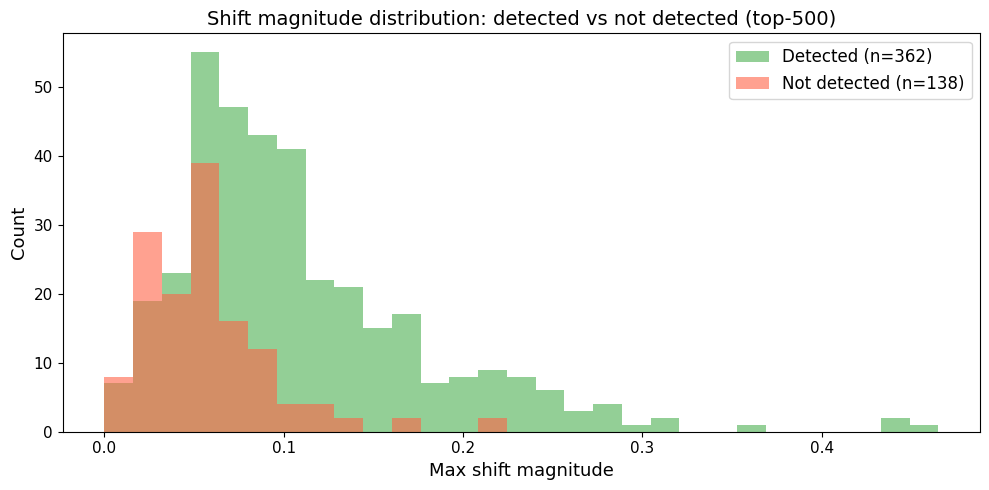

In [ ]:
import ast
import math
import os
import matplotlib.pyplot as plt
import numpy as np

RESULTS_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_angle_preserving_out_500\results.txt"
TOP_K = 500

# --- Parse results.txt -> max shift magnitude per sample ---
def _parse_displacement(path):
    disp_map = {}
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split(" | ")
            kv = {k.strip(): v.strip() for p in parts for k, _, v in [p.partition(": ")] if _}
            img_path = kv.get("image_path", "")
            person_id_raw = kv.get("person_id")
            if not img_path or person_id_raw is None:
                continue
            try:
                person_id = int(person_id_raw)
            except (ValueError, TypeError):
                continue
            shift_vectors = ast.literal_eval(kv.get("shift_vectors", "[]"))
            mags = [math.hypot(sv[0], sv[1]) for sv in shift_vectors
                    if sv[0] != 0.0 or sv[1] != 0.0]
            max_disp = max(mags) if mags else 0.0
            key = (os.path.normcase(img_path), person_id)
            disp_map[key] = max_disp
    return disp_map

ref_displacement = _parse_displacement(RESULTS_TXT_500)

# --- Re-run evaluator to get combined_ranking (same setup as test()) ---
_dataset_500 = YOLOPoseDataset(
    r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_angle_preserving_out_500\train.txt"
)
_validator_500 = YPSetValidation(_dataset_500)
_evaluator_500 = MergedRankingEvaluator(
    validator=_validator_500,
    report_paths={"rigid_aligned": RESULTS_TXT_500},
    top_k=TOP_K,
    output_path=None,
    distance_model_name="random_forest",
    distance_visibility_threshold=2.0,
    distance_threshold_percentile=95.0,
    distance_sort_by="mean",
    segmentation_mask_tolerance_px=18,
)
_result_500 = _evaluator_500.run(
    distance_weight=0.5,
    lbp_weight=0.1,
    segmentation_weight=0.4,
)

# Set of keys detected within top-k
detected_keys = {
    (os.path.normcase(str(e["image_path"])), int(e["person_id"]))
    for e in _result_500["combined_ranking"]
    if e.get("rank", float("inf")) <= TOP_K
}

# Also count outside_mentioned_in_merged as detected (outside keys in the reference,
# which may have rank > TOP_K when there are more outside entries than TOP_K)
_outside_keys_eval = {
    key
    for key, meta in _evaluator_500.outside_lookup.items()
    if bool(meta.get("outside_mask_detected", False))
}
_outside_mentioned_keys = _outside_keys_eval & _evaluator_500.merged_reference_keys
detected_keys = detected_keys | _outside_mentioned_keys

# --- Build per-sample arrays ---
detected_disp = np.array([d for k, d in ref_displacement.items() if k in detected_keys])
not_detected_disp = np.array([d for k, d in ref_displacement.items() if k not in detected_keys])

print(f"Detected: {len(detected_disp)}, Not detected: {len(not_detected_disp)}")

# IEEE-like styling: serif fonts, neutral palette, and print-friendly lines.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1.0,
})

# --- Plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5), tight_layout=True)

all_disp = np.concatenate([detected_disp, not_detected_disp])
bins = np.linspace(0, all_disp.max() * 1.02, 30)

ax1.hist(
    detected_disp,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#5A5A5A",
    edgecolor="black",
    linewidth=0.7,
    label=f"Detected (n={len(detected_disp)})",
)
ax1.hist(
    not_detected_disp,
    bins=bins,
    density=False,
    alpha=0.75,
    color="#C9C9C9",
    edgecolor="black",
    linewidth=0.7,
    hatch="//",
    label=f"Not detected (n={len(not_detected_disp)})",
)

ax1.set_xlabel("Max shift magnitude", fontsize=17)
ax1.set_ylabel("Count", fontsize=17)
ax1.tick_params(axis="both", labelsize=13)
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
ax1.legend(fontsize=12, frameon=True, edgecolor="black")

plt.show()
